In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.loader import fetch_prices
from pairs.selection import compute_correlation_matrix, find_pairs, compute_spread

## Configuration
Edit this cell to switch universes. Everything below adapts automatically.

In [2]:
# --- Configuration ---
TICKERS = ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
START = '2010-01-01'
END   = '2024-12-31'
P_THRESHOLD = 0.05
INSPECT_PAIR = None  # set to ('TICK1', 'TICK2') to override auto-selected best pair

## 1. Load Data

In [3]:
prices = fetch_prices(TICKERS, START, END)
prices.tail()

,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,
2024-12-23,41.704441,40.608582,47.755322,131.315491,118.298065,76.821594,39.190346,36.973854,136.351700,113.602119
2024-12-24,41.929947,40.952103,48.317501,132.341415,119.520447,77.327774,39.451363,37.178028,136.911850,116.229393
2024-12-26,41.866219,40.918240,48.435852,132.440048,119.599953,77.571121,39.509361,37.090527,137.187027,115.798134
2024-12-27,41.640713,40.913399,48.080795,131.453598,118.009850,77.191505,39.190346,36.983578,136.548248,113.884682
2024-12-30,41.081841,40.908562,47.617245,130.131760,116.509201,76.286217,39.006672,36.828018,134.867813,112.055504


## 2. Correlation Matrix

**What is correlation?**
Correlation is a number between -1 and 1 measuring how similarly two stocks move day to day. A value near 1 means they tend to go up and down together. Near 0 means they move independently. The key limitation: correlation only captures daily co-movement. It says nothing about whether prices stay close together over months or years.

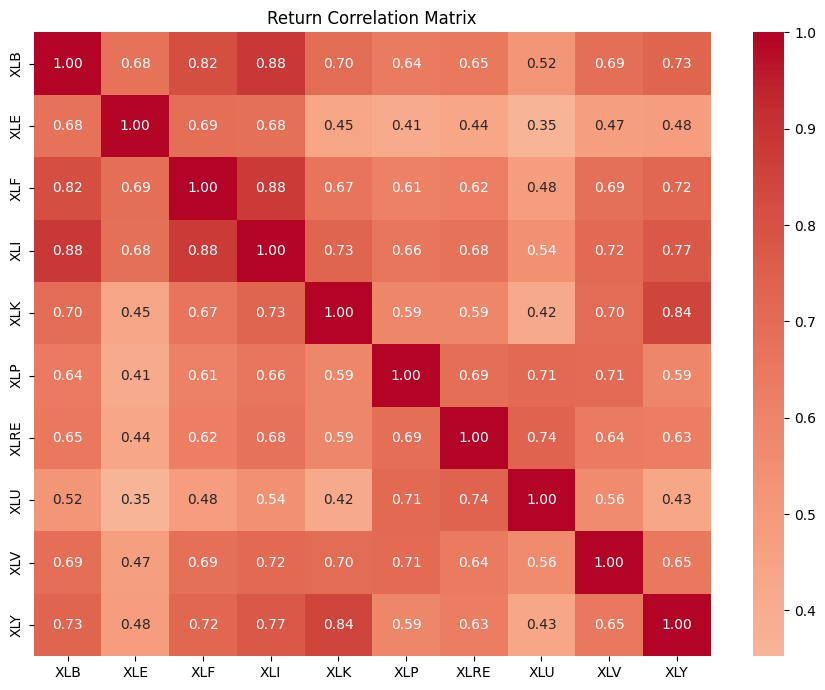

In [4]:
corr = compute_correlation_matrix(prices)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Return Correlation Matrix')
plt.tight_layout()
plt.show()

> **Observations - Correlation Matrix**
>
> Most of these sector ETFs have pairwise correlations between 0.70 and 0.90. That is high, but not surprising. All ten sectors respond to the same macroeconomic drivers (rate changes, inflation, recession fears), so they tend to move together in the short run.
>
> The lowest pairwise correlation in the matrix is between **XLU** (utilities) and **XLE** (energy). This is less intuitive than it looks. Utilities are regulated businesses with predictable cash flows and high dividend yields, so their stock prices trade like long-duration bonds: they rise when interest rates fall and fall when rates rise. Energy companies are commodity-driven: their valuations move with oil and gas prices, which are largely independent of the rate cycle. Two sectors can be operationally linked and still have low equity return correlation if their valuations respond to different macro forces.
>
> High correlation does not mean the prices stay close together. Two stocks can move in the same direction every day and still drift apart over years. Correlation and cointegration are measuring different things, and for pairs trading, correlation is the less useful of the two.

## 3. Cointegration Screen

**What is cointegration?**
Cointegration measures whether the price gap between two stocks stays stable over a long period. Two stocks can be cointegrated even if they do not move in sync every day, as long as the gap between them has a consistent average it keeps returning to. That reversion is what the strategy trades on. A pair fails the test if the gap just keeps growing or drifting with no tendency to reverse.

**What is a p-value?**
A p-value is the probability that the observed result is just random noise. A p-value of 0.05 means a 5% chance the result is a fluke. Lower is better. We use 0.05 as the cutoff, meaning only pairs where we are at least 95% confident the gap is genuinely stable pass through.

In [5]:
pairs = find_pairs(prices, p_threshold=P_THRESHOLD)
print(f"Found {len(pairs)} cointegrated pair(s) at p < {P_THRESHOLD}\n")
for p in pairs:
    print(f"{p['pair'][0]}/{p['pair'][1]}  p={p['pvalue']:.4f}  hedge={p['hedge_ratio']:.4f}")

Found 8 cointegrated pair(s) at p < 0.05

XLP/XLU  p=0.0007  hedge=2.1292
XLP/XLV  p=0.0037  hedge=0.4614
XLB/XLV  p=0.0124  hedge=0.2617
XLU/XLV  p=0.0141  hedge=0.2117
XLF/XLI  p=0.0229  hedge=0.3425
XLU/XLY  p=0.0384  hedge=0.3001
XLB/XLU  p=0.0487  hedge=1.1838
XLV/XLY  p=0.0491  hedge=1.4075


> **Observations - Cointegration Screen**
>
> The test is asking whether the price gap between two stocks is stationary, meaning it has a fixed average it consistently returns to rather than drifting off indefinitely. The p-value measures the probability that what we observe is just a random walk. Below 0.05, we treat the relationship as real.
>
> **XLP/XLU is the strongest result at p=0.0007**, well below any reasonable threshold. Its correlation of 0.73 is lower than several other pairs in the universe, yet it tops the cointegration screen. That disconnect is the key point: high correlation did not predict which pairs would pass the cointegration test. The two screens are measuring different things.
>
> **XLP** is the consumer staples ETF (Procter & Gamble, Coca-Cola, Costco). **XLU** is utilities (NextEra Energy, Duke Energy). They are in different industries, but both are defensive sectors that behave like bond proxies when interest rates move. That shared rate sensitivity is likely what the cointegration test is picking up. It is a coincidental macro link rather than a structural one, which is a concern worth keeping in mind as the strategy develops.

## 4. Inspect Pair

**What is the spread?**
The spread is the price gap between the two stocks after adjusting for scale. Since the two ETFs rarely trade at the same price, one is multiplied by a hedge ratio before subtracting. The ratio is estimated so the resulting gap is as stationary as possible. A spread that bounces around a flat average is what we want.

**What is the z-score?**
The z-score converts the spread into standardized units. A z-score of 0 means the gap is at its historical average. A value of +2 means it is 2 standard deviations above average, which is the entry signal: short the expensive leg, buy the cheap one, close when it returns to 0.

**What is the hedge ratio?**
The hedge ratio specifies how many shares of stock B to hold per share of stock A. It is estimated by OLS regression so the combined position is approximately dollar-neutral. A ratio of 0.34 means: for every 1 share of XLB, sell 0.34 shares of XLV.

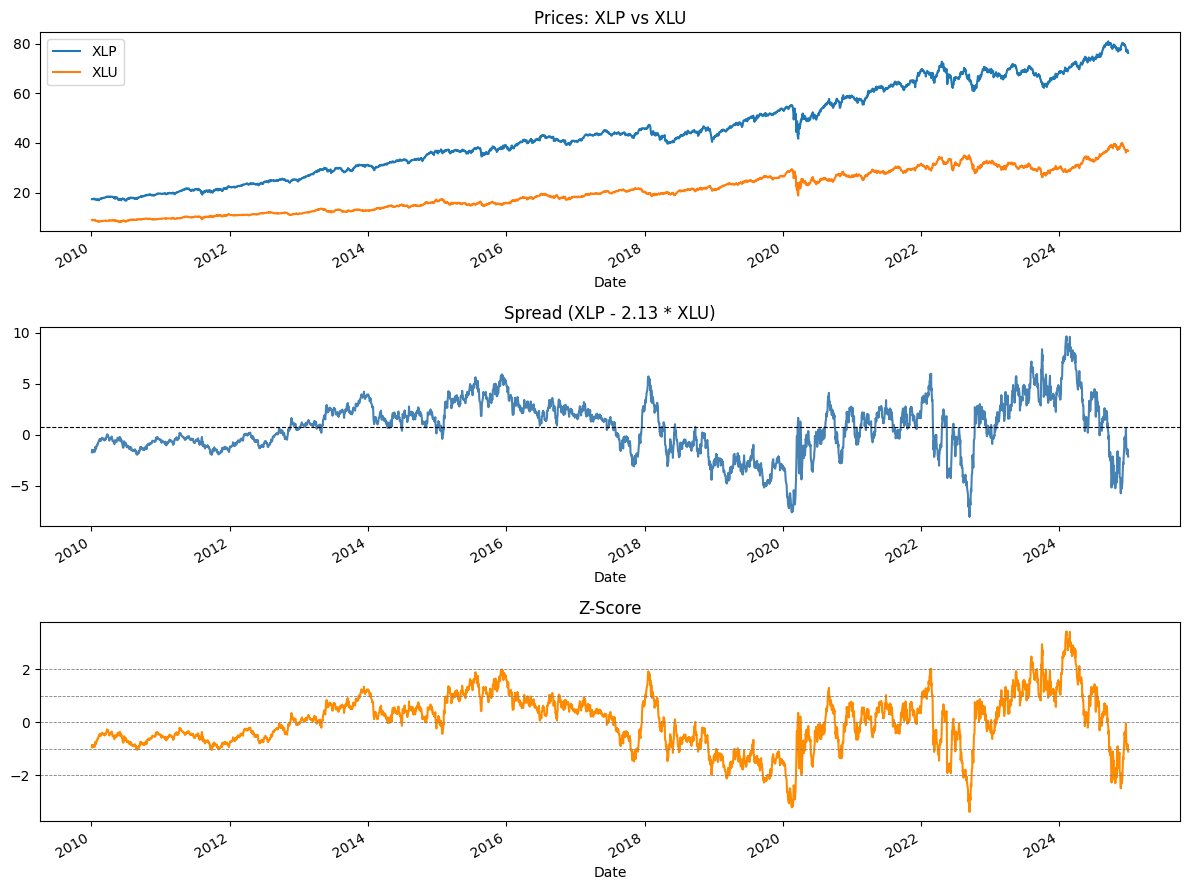


Inspecting: XLP/XLU  hedge=2.1292


In [6]:
if not pairs:
    print('No cointegrated pairs found. Try relaxing P_THRESHOLD or expanding the universe.')
else:
    if INSPECT_PAIR:
        t1, t2 = INSPECT_PAIR
        match = next((p for p in pairs if set(p['pair']) == {t1, t2}), None)
        hedge_ratio = match['hedge_ratio'] if match else 1.0
    else:
        best = pairs[0]
        t1, t2 = best['pair']
        hedge_ratio = best['hedge_ratio']

    spread = compute_spread(prices, t1, t2, hedge_ratio)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9))

    prices[[t1, t2]].plot(ax=axes[0], title=f'Prices: {t1} vs {t2}')

    spread.plot(ax=axes[1], title=f'Spread ({t1} - {hedge_ratio:.2f} * {t2})', color='steelblue')
    axes[1].axhline(spread.mean(), color='k', linestyle='--', linewidth=0.8)

    zscore = (spread - spread.mean()) / spread.std()
    zscore.plot(ax=axes[2], title='Z-Score', color='darkorange')
    for level in [-2, -1, 0, 1, 2]:
        axes[2].axhline(level, color='grey', linestyle='--', linewidth=0.6)

    plt.tight_layout()
    plt.show()
    print(f'\nInspecting: {t1}/{t2}  hedge={hedge_ratio:.4f}')

> **Observations - Pair Chart**
>
> This chart shows **XLP/XLU** (p=0.0007, hedge=2.1292): one unit of XLP matched against 2.13 units of XLU. It is the top result by p-value from the cointegration screen.
>
> **Panel 1 - Prices.** Both ETFs trend upward across the period and their shapes track each other reasonably well. No sustained divergence is visible, which is consistent with the cointegration result.
>
> **Panel 2 - Spread.** The spread crosses its mean roughly 112 times over the 14-year period, about 7-8 times per year. That is a reasonable trade frequency. But some years show persistent drift: 2015 and 2023 both have the spread sitting far above average for extended stretches, and 2020 and 2022 both dip well below. Persistent one-sided movement without quick reversion means positions held through those periods would have lost for a long time before recovering.
>
> **Panel 3 - Z-score.** The z-score reaches ±2 frequently enough to generate entries, and the full range is -3.38 to +3.42 over the period. Stop-loss levels at ±3 were breached in both 2020 (z=-3.21) and 2022 (z=-3.38).
>
> The statistics are the strongest in the universe, but the economic story is thin. XLP (consumer staples) and XLU (utilities) are both defensive sectors that behave like bond proxies when rates move, which likely explains the cointegration. That is a coincidental macro link, not a structural one. XLP also appears in the second-ranked pair (XLP/XLV), which means the top two candidates share a leg and are not independent. Notebook 02 proceeds with XLB/XLV for those reasons.